# BCHH response correction using Antelope calibration

This standalone notebook reconstructs the 2016 BCHH calibration workflow.

**Authoritative pressure scaling:** the event-epoch values in the Antelope `sitedb.calibration` table. The nominal infraBSU/NRL response is retained for response-shape and provenance comparisons, but it is not assumed to provide the correct channel-specific Pa/count values.


## 1. Imports and configuration

Edit only the paths and time windows in this section before running the notebook.


In [1]:
from __future__ import annotations

import copy
import json
import os
from pathlib import Path
from typing import Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from obspy import Stream, UTCDateTime, read, read_inventory
from obspy.clients.nrl import NRL
from obspy.core.inventory import Channel, Inventory, Network, Site, Station
from obspy.core.inventory.response import InstrumentSensitivity, Response

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})


In [2]:
INFRABSU_BUILDER_VERSION = "2026-07-12-v3-antelope-calibration"
print("Running infraBSU builder:", INFRABSU_BUILDER_VERSION)


Running infraBSU builder: 2026-07-12-v3-antelope-calibration


In [24]:
# Project paths
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

MINISEED_DIR = Path(
    "/Volumes/haldata/KSC/beforePASSCAL/EVENTS/20160901_SpaceXplosion"
)
STATIONXML_FILE = PROJECT_ROOT / "metadata" / "KSC.xml"
CORRECTED_STATIONXML = PROJECT_ROOT / "metadata" / "KSC_calibration_corrected_from_antelope_site_db.xml"

# Antelope CSS3.0 tables from the original 2016 processing workflow.
# Edit these paths if the files are stored elsewhere.
CSS_CALIBRATION_FILE = PROJECT_ROOT / "metadata" / "sitedb.calibration"
CSS_SITE_FILE = PROJECT_ROOT / "metadata" / "sitedb.site"
CSS_SITECHAN_FILE = PROJECT_ROOT / "metadata" / "sitedb.sitechan"

# Previously downloaded sensor-only infraBSU StationXML template.
INFRABSU_TEMPLATE_FILE = (
    PROJECT_ROOT.parent.parent
    / "flovopy"
    / "flovopy"
    / "stationmetadata"
    / "stationxml_templates"
    / "infraBSU_sensor.xml"
)

# None means use ObsPy's remote NRL for the Centaur stages.
NRL_PATH = None

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "response_correction"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_CACHE = OUTPUT_DIR / "bchh_raw_event_window.mseed"
CORRECTED_MSEED = OUTPUT_DIR / "bchh_corrected_antelope_calibration.mseed"
ORIGINAL_EVENT_STATIONXML = OUTPUT_DIR / "bchh_event_inventory_original.xml"
CALIBRATED_EVENT_STATIONXML = OUTPUT_DIR / "bchh_event_inventory_antelope_calibrated.xml"
CHANNEL_METADATA_CSV = OUTPUT_DIR / "bchh_channel_metadata.csv"
ACTIVE_CALIBRATION_CSV = OUTPUT_DIR / "bchh_active_antelope_calibration.csv"
CORRECTION_SUMMARY_CSV = OUTPUT_DIR / "bchh_correction_summary.csv"
NRL_COMPARISON_CSV = OUTPUT_DIR / "infrabsu_nrl_response_comparison.csv"
PROCESSING_JSON = OUTPUT_DIR / "bchh_response_processing.json"

OVERWRITE_RAW_CACHE = False
OVERWRITE_CORRECTED = True

EXPLOSION_TIME = UTCDateTime("2016-09-01T13:07:12.080")
READ_START = EXPLOSION_TIME - 180.0
READ_END = EXPLOSION_TIME + 1800.0

# Quiet interval used to remove each pressure channel's raw-count DC offset.
PRESSURE_BASELINE_START = EXPLOSION_TIME - 20.0
PRESSURE_BASELINE_END = EXPLOSION_TIME - 2.0

SEISMIC_PRE_FILT = (0.02, 0.05, 80.0, 100.0)
SEISMIC_WATER_LEVEL_DB = 60.0

BCHH_NETWORK = "1R"
BCHH_STATION = "BCHH"
BCHH_LOCATION = "10"

WAVEFORM_TO_XML_CHANNEL = {
    "HD1": "DD1",
    "HD2": "DD2",
    "HD3": "DD3",
    "HHE": "DHE",
    "HHN": "DHN",
    "HHZ": "DHZ",
}
XML_TO_WAVEFORM_CHANNEL = {v: k for k, v in WAVEFORM_TO_XML_CHANNEL.items()}
CHANNEL_ORDER = list(WAVEFORM_TO_XML_CHANNEL)

for required_path, label in [
    (STATIONXML_FILE, "event StationXML"),
    (CSS_CALIBRATION_FILE, "Antelope calibration table"),
    (INFRABSU_TEMPLATE_FILE, "infraBSU sensor template"),
]:
    if not required_path.exists():
        print(f"WARNING: {label} not found at {required_path}")


## 2. Load and subset the event inventory

Coordinates, elevations, channel orientations, sample rates, and responses are all taken from the active StationXML epoch. No station coordinates are hardcoded.


In [6]:
def load_event_inventory(
    stationxml_file: Path,
    *,
    network: str,
    station: str,
    location: str,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
) -> Inventory:
    """Load the StationXML and retain only active BCHH channel epochs."""
    if not stationxml_file.exists():
        raise FileNotFoundError(stationxml_file)

    inventory = read_inventory(str(stationxml_file))
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        time=starttime,
    )

    # Retain only channels that overlap the requested time interval.
    keep = set(WAVEFORM_TO_XML_CHANNEL.values())
    selected = copy.deepcopy(selected)
    for net in selected:
        for sta in net:
            sta.channels = [
                cha for cha in sta.channels
                if cha.code in keep
                and (cha.start_date is None or cha.start_date <= endtime)
                and (cha.end_date is None or cha.end_date >= starttime)
            ]

    if not any(sta.channels for net in selected for sta in net):
        raise ValueError("No active BCHH response channels found in StationXML")

    return selected


def inventory_channels_to_dataframe(inventory: Inventory) -> pd.DataFrame:
    """Flatten channel coordinates and response sensitivities into a table."""
    rows = []
    for net in inventory:
        for sta in net:
            for cha in sta:
                response = cha.response
                sensitivity = getattr(response, "instrument_sensitivity", None)
                rows.append({
                    "seed_id": f"{net.code}.{sta.code}.{cha.location_code}.{cha.code}",
                    "network": net.code,
                    "station": sta.code,
                    "location": cha.location_code,
                    "channel": cha.code,
                    "waveform_channel": XML_TO_WAVEFORM_CHANNEL.get(cha.code),
                    "latitude": float(cha.latitude),
                    "longitude": float(cha.longitude),
                    "elevation_m": float(cha.elevation),
                    "depth_m": float(cha.depth),
                    "azimuth_deg": None if cha.azimuth is None else float(cha.azimuth),
                    "dip_deg": None if cha.dip is None else float(cha.dip),
                    "sample_rate_hz": None if cha.sample_rate is None else float(cha.sample_rate),
                    "sensitivity": None if sensitivity is None else float(sensitivity.value),
                    "sensitivity_frequency_hz": None if sensitivity is None else float(sensitivity.frequency),
                    "input_units": None if sensitivity is None else str(sensitivity.input_units),
                    "output_units": None if sensitivity is None else str(sensitivity.output_units),
                })
    return pd.DataFrame(rows).sort_values("channel").reset_index(drop=True)


inventory_event = load_event_inventory(
    STATIONXML_FILE,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    starttime=READ_START,
    endtime=READ_END,
)

channel_metadata_df = inventory_channels_to_dataframe(inventory_event)
display(channel_metadata_df)

inventory_event.write(str(CORRECTED_STATIONXML), format="STATIONXML", validate=True)
channel_metadata_df.to_csv(CHANNEL_METADATA_CSV, index=False)
print(f"Saved event inventory: {CORRECTED_STATIONXML}")
print(f"Saved channel coordinates: {CHANNEL_METADATA_CSV}")


,seed_id,network,station,location,channel,waveform_channel,latitude,longitude,elevation_m,depth_m,azimuth_deg,dip_deg,sample_rate_hz,sensitivity,sensitivity_frequency_hz,input_units,output_units
0,1R.BCHH.10.DD1,1R,BCHH,10,DD1,HD1,28.574222,-80.572417,0.0,0.0,0.0,0.0,250.0,1.840000e+01,1.0,Pa,count
1,1R.BCHH.10.DD2,1R,BCHH,10,DD2,HD2,28.573881,-80.572296,0.0,0.0,90.0,0.0,250.0,1.840000e+01,1.0,Pa,count
2,1R.BCHH.10.DD3,1R,BCHH,10,DD3,HD3,28.574006,-80.572560,0.0,0.0,0.0,0.0,250.0,1.840000e+01,1.0,Pa,count
3,1R.BCHH.10.DHE,1R,BCHH,10,DHE,HHE,28.574017,-80.572376,0.0,0.0,90.0,0.0,250.0,3.017200e+08,1.0,m/s,count
4,1R.BCHH.10.DHN,1R,BCHH,10,DHN,HHN,28.574017,-80.572376,0.0,0.0,0.0,0.0,250.0,3.017200e+08,1.0,m/s,count
5,1R.BCHH.10.DHZ,1R,BCHH,10,DHZ,HHZ,28.574017,-80.572376,0.0,0.0,0.0,-90.0,250.0,3.017200e+08,1.0,m/s,count


Saved event inventory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/metadata/KSC_calibration_corrected_from_antelope_site_db.xml
Saved channel coordinates: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_channel_metadata.csv


## 3. Read and cache the raw BCHH stream


In [7]:
def read_bchh_stream(
    miniseed_dir: Path,
    cache_file: Path,
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    *,
    overwrite_cache: bool = False,
) -> Stream:
    """Read BCHH day files, trim, merge, and optionally cache the raw counts."""
    if cache_file.exists() and not overwrite_cache:
        st = read(str(cache_file))
        st.trim(starttime, endtime, pad=False)
        return st

    patterns = ["*.20160901T000000", "*.mseed", "*.msd", "*.miniseed"]
    files = []
    for pattern in patterns:
        files.extend(miniseed_dir.glob(pattern))
    files = sorted(set(files))

    if not files:
        raise FileNotFoundError(f"No miniSEED files found in {miniseed_dir}")

    st = Stream()
    for filename in files:
        st += read(str(filename))

    st.trim(starttime, endtime, pad=False)
    st.merge(method=1, fill_value="interpolate")
    st.sort(keys=["station", "channel"])
    st.write(str(cache_file), format="MSEED")
    return st


st_raw = read_bchh_stream(
    MINISEED_DIR,
    RAW_CACHE,
    READ_START,
    READ_END,
    overwrite_cache=OVERWRITE_RAW_CACHE,
)

print(st_raw)
for tr in st_raw:
    print(tr.id, tr.stats.starttime, tr.stats.endtime, tr.stats.sampling_rate, tr.stats.npts)


9 Trace(s) in Stream:
FL.BCHH.00.HD1 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD1 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD2 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD2 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HD3 | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.10.HD3 | 2016-09-01T13:07:00.000000Z - 2016-09-01T13:10:00.000000Z | 250.0 Hz, 45001 samples
FL.BCHH.00.HHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
FL.BCHH.00.HD1 2016-09-01T13:04:12.080000Z 2016-09-01T13:37:12.

## 4. Read the original Antelope calibration table

For pressure channels, Antelope `calib` is interpreted as the multiplier from raw counts to physical units. Thus the event-epoch values are directly in **Pa/count**. These channel-specific empirical values are authoritative for the Fireball processing.


In [9]:
def read_css_calibration_table(path: Path | str) -> pd.DataFrame:
    """Read the fields needed from an Antelope CSS3.0 calibration table.

    The instrument and recorder descriptions contain spaces, so fields are
    extracted from both ends of each whitespace-delimited row:
      sta, chan, time, endtime, ..., calib, calper, tshift, units, lddate
    """
    rows = []
    path = Path(path)
    for line_number, line in enumerate(path.read_text().splitlines(), start=1):
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        fields = line.split()
        if len(fields) < 10:
            raise ValueError(f"Malformed calibration row {line_number}: {line}")
        rows.append({
            "station": fields[0],
            "css_channel": fields[1],
            "start_epoch": float(fields[2]),
            "end_epoch": float(fields[3]),
            "calib": float(fields[-5]),
            "calper": float(fields[-4]),
            "tshift": float(fields[-3]),
            "units": fields[-2],
            "lddate_epoch": float(fields[-1]),
            "line_number": line_number,
            "raw_line": line,
        })
    return pd.DataFrame(rows)


def active_css_calibrations(
    table: pd.DataFrame,
    *,
    station: str,
    event_time: UTCDateTime,
    waveform_channels: Iterable[str],
) -> pd.DataFrame:
    """Select exactly one active calibration row for each waveform channel."""
    event_epoch = float(event_time.timestamp)
    selected_rows = []

    for waveform_channel in waveform_channels:
        css_channel = f"{waveform_channel}_00"
        matches = table[
            (table["station"] == station)
            & (table["css_channel"] == css_channel)
            & (table["start_epoch"] <= event_epoch)
            & (table["end_epoch"] >= event_epoch)
        ]
        if len(matches) != 1:
            raise ValueError(
                f"Expected one active calibration for {station}.{css_channel} "
                f"at {event_time}; found {len(matches)}"
            )
        selected_rows.append(matches.iloc[0])

    result = pd.DataFrame(selected_rows).reset_index(drop=True)
    result["waveform_channel"] = result["css_channel"].str.replace(
        "_00", "", regex=False
    )
    result["count_per_unit"] = 1.0 / result["calib"]
    return result


css_calibration_df = read_css_calibration_table(CSS_CALIBRATION_FILE)
active_pressure_calibration_df = active_css_calibrations(
    css_calibration_df,
    station=BCHH_STATION,
    event_time=EXPLOSION_TIME,
    waveform_channels=["HD1", "HD2", "HD3"],
)

print("Active empirical pressure calibrations:")
display(
    active_pressure_calibration_df[
        [
            "waveform_channel",
            "start_epoch",
            "end_epoch",
            "calib",
            "units",
            "count_per_unit",
        ]
    ]
)

pressure_calib_pa_per_count = dict(
    zip(
        active_pressure_calibration_df["waveform_channel"],
        active_pressure_calibration_df["calib"],
    )
)

for channel, value in pressure_calib_pa_per_count.items():
    print(f"{channel}: {value:g} Pa/count ({1.0/value:g} count/Pa)")


Active empirical pressure calibrations:


,waveform_channel,start_epoch,end_epoch,calib,units,count_per_unit
0,HD1,1.463530e+09,1.473379e+09,0.1234,Pa,8.103728
1,HD2,1.463530e+09,1.473379e+09,1.4499,Pa,0.689703
2,HD3,1.463530e+09,1.473379e+09,0.1000,Pa,10.000000


HD1: 0.1234 Pa/count (8.10373 count/Pa)
HD2: 1.4499 Pa/count (0.689703 count/Pa)
HD3: 0.1 Pa/count (10 count/Pa)


## 4. Production correction using the event StationXML

The pressure and seismic channels are treated differently:

- **infraBSU (`HD*`)**: counts are divided by the StationXML overall sensitivity. The response is approximately flat over the analysis band, and this avoids unstable inversion near zero frequency. A pre-event median is then removed to eliminate the digitizer DC offset.
- **Trillium Compact (`HH*`)**: the complete response is removed to velocity using a pre-filter and finite water level.

The original waveform IDs are restored after response lookup.


In [10]:
def remap_trace_to_inventory_id(
    trace,
    *,
    inventory_network: str,
    inventory_station: str,
    inventory_location: str,
):
    """Copy a waveform trace and temporarily assign its StationXML NSLC code."""
    out = trace.copy()
    waveform_channel = out.stats.channel.upper()
    if waveform_channel not in WAVEFORM_TO_XML_CHANNEL:
        raise ValueError(f"No StationXML mapping defined for {trace.id}")

    original_codes = {
        "network": out.stats.network,
        "station": out.stats.station,
        "location": out.stats.location,
        "channel": out.stats.channel,
    }
    out.stats.network = inventory_network
    out.stats.station = inventory_station
    out.stats.location = inventory_location
    out.stats.channel = WAVEFORM_TO_XML_CHANNEL[waveform_channel]
    return out, original_codes


def restore_trace_id(trace, original_codes: dict) -> None:
    for key, value in original_codes.items():
        setattr(trace.stats, key, value)


def median_in_window(trace, starttime: UTCDateTime, endtime: UTCDateTime) -> float:
    window = trace.copy().trim(starttime, endtime, pad=False)
    if window.stats.npts == 0:
        raise ValueError(f"No samples in baseline window for {trace.id}")
    return float(np.nanmedian(np.asarray(window.data, dtype=np.float64)))


def correct_bchh_with_antelope_calibration(
    stream: Stream,
    inventory: Inventory,
    *,
    pressure_calib_pa_per_count: dict[str, float],
    inventory_network: str,
    inventory_station: str,
    inventory_location: str,
    pressure_baseline_start: UTCDateTime,
    pressure_baseline_end: UTCDateTime,
    seismic_pre_filt: tuple[float, float, float, float],
    seismic_water_level_db: float,
) -> tuple[Stream, pd.DataFrame]:
    """Correct BCHH pressure with Antelope calib and seismic with StationXML."""
    corrected = Stream()
    rows = []

    for raw_trace in stream:
        xml_trace, original_codes = remap_trace_to_inventory_id(
            raw_trace,
            inventory_network=inventory_network,
            inventory_station=inventory_station,
            inventory_location=inventory_location,
        )
        response = inventory.get_response(xml_trace.id, xml_trace.stats.starttime)
        sensitivity = response.instrument_sensitivity
        waveform_channel = original_codes["channel"].upper()

        if waveform_channel.startswith("HD"):
            if waveform_channel not in pressure_calib_pa_per_count:
                raise KeyError(f"No empirical calibration for {waveform_channel}")

            calib_pa_per_count = float(
                pressure_calib_pa_per_count[waveform_channel]
            )
            out = raw_trace.copy()
            out.data = np.asarray(out.data, dtype=np.float64)

            baseline_counts = median_in_window(
                out,
                pressure_baseline_start,
                pressure_baseline_end,
            )
            out.data = (out.data - baseline_counts) * calib_pa_per_count

            baseline_physical = baseline_counts * calib_pa_per_count
            units = "Pa"
            method = "antelope_calib_after_pre_event_count_baseline"
            effective_count_per_unit = 1.0 / calib_pa_per_count
            pre_filt = None
            water_level = None

        elif waveform_channel.startswith("HH"):
            out = xml_trace.copy()
            out.detrend("demean")
            out.detrend("linear")
            out.taper(max_percentage=0.05, type="cosine")
            out.remove_response(
                inventory=inventory,
                output="VEL",
                pre_filt=seismic_pre_filt,
                water_level=seismic_water_level_db,
                zero_mean=False,
                taper=False,
            )
            restore_trace_id(out, original_codes)

            calib_pa_per_count = np.nan
            baseline_counts = np.nan
            baseline_physical = np.nan
            units = "m/s"
            method = "event_stationxml_full_response_to_velocity"
            effective_count_per_unit = float(sensitivity.value)
            pre_filt = seismic_pre_filt
            water_level = seismic_water_level_db
        else:
            raise ValueError(f"Unsupported waveform channel {raw_trace.id}")

        out.stats.units = units
        corrected += out
        rows.append({
            "waveform_id": raw_trace.id,
            "inventory_id": xml_trace.id,
            "method": method,
            "units": units,
            "antelope_calib_pa_per_count": calib_pa_per_count,
            "effective_count_per_unit": effective_count_per_unit,
            "stationxml_nominal_sensitivity": float(sensitivity.value),
            "stationxml_input_units": str(sensitivity.input_units),
            "stationxml_output_units": str(sensitivity.output_units),
            "removed_baseline_counts": baseline_counts,
            "removed_baseline_physical_units": baseline_physical,
            "pre_filt": None if pre_filt is None else repr(tuple(pre_filt)),
            "water_level_db": water_level,
        })

    corrected.sort(keys=["station", "channel"])
    return corrected, pd.DataFrame(rows)


st_corrected, correction_summary_df = correct_bchh_with_antelope_calibration(
    st_raw,
    inventory_event,
    pressure_calib_pa_per_count=pressure_calib_pa_per_count,
    inventory_network=BCHH_NETWORK,
    inventory_station=BCHH_STATION,
    inventory_location=BCHH_LOCATION,
    pressure_baseline_start=PRESSURE_BASELINE_START,
    pressure_baseline_end=PRESSURE_BASELINE_END,
    seismic_pre_filt=SEISMIC_PRE_FILT,
    seismic_water_level_db=SEISMIC_WATER_LEVEL_DB,
)

display(correction_summary_df)


,waveform_id,inventory_id,method,units,antelope_calib_pa_per_count,effective_count_per_unit,stationxml_nominal_sensitivity,stationxml_input_units,stationxml_output_units,removed_baseline_counts,removed_baseline_physical_units,pre_filt,water_level_db
0,FL.BCHH.00.HD1,1R.BCHH.10.DD1,antelope_calib_after_pre_event_count_baseline,Pa,0.1234,8.103728e+00,1.840000e+01,Pa,count,-367519.0,-45351.8446,NaN,NaN
1,FL.BCHH.10.HD1,1R.BCHH.10.DD1,antelope_calib_after_pre_event_count_baseline,Pa,0.1234,8.103728e+00,1.840000e+01,Pa,count,-367970.0,-45407.4980,NaN,NaN
2,FL.BCHH.00.HD2,1R.BCHH.10.DD2,antelope_calib_after_pre_event_count_baseline,Pa,1.4499,6.897027e-01,1.840000e+01,Pa,count,1921.0,2785.2579,NaN,NaN
3,FL.BCHH.10.HD2,1R.BCHH.10.DD2,antelope_calib_after_pre_event_count_baseline,Pa,1.4499,6.897027e-01,1.840000e+01,Pa,count,1922.0,2786.7078,NaN,NaN
4,FL.BCHH.00.HD3,1R.BCHH.10.DD3,antelope_calib_after_pre_event_count_baseline,Pa,0.1000,1.000000e+01,1.840000e+01,Pa,count,23215.0,2321.5000,NaN,NaN
5,FL.BCHH.10.HD3,1R.BCHH.10.DD3,antelope_calib_after_pre_event_count_baseline,Pa,0.1000,1.000000e+01,1.840000e+01,Pa,count,23218.0,2321.8000,NaN,NaN
6,FL.BCHH.00.HHE,1R.BCHH.10.DHE,event_stationxml_full_response_to_velocity,m/s,NaN,3.017200e+08,3.017200e+08,m/s,count,NaN,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0
7,FL.BCHH.00.HHN,1R.BCHH.10.DHN,event_stationxml_full_response_to_velocity,m/s,NaN,3.017200e+08,3.017200e+08,m/s,count,NaN,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0
8,FL.BCHH.00.HHZ,1R.BCHH.10.DHZ,event_stationxml_full_response_to_velocity,m/s,NaN,3.017200e+08,3.017200e+08,m/s,count,NaN,NaN,"(0.02, 0.05, 80.0, 100.0)",60.0


## 6. Build an Antelope-calibrated response inventory

For each DD channel, the first response-stage gain is rescaled so that the total response sensitivity equals `1 / calib` count/Pa. This preserves the nominal infraBSU pole-zero shape while recording the empirical channel-specific amplitude calibration.


In [14]:
def make_antelope_calibrated_inventory(
    inventory: Inventory,
    *,
    network: str,
    station: str,
    location: str,
    channel_calib_pa_per_count: dict[str, float],
    waveform_to_xml_channel: dict[str, str],
    time: UTCDateTime,
) -> Inventory:
    """Return a copy of the inventory with empirical pressure calibrations.

    The Antelope calibration is in Pa/count, so the corresponding StationXML
    sensitivity is its reciprocal, in count/Pa.

    The first response-stage gain is rescaled so the complete response has the
    desired empirical overall sensitivity while retaining its pole-zero shape.
    """
    calibrated = copy.deepcopy(inventory)

    for waveform_channel, calib_pa_per_count in (
        channel_calib_pa_per_count.items()
    ):
        if waveform_channel not in waveform_to_xml_channel:
            raise KeyError(
                f"No StationXML channel mapping for {waveform_channel}"
            )

        xml_channel = waveform_to_xml_channel[waveform_channel]

        selected = calibrated.select(
            network=network,
            station=station,
            location=location,
            channel=xml_channel,
            time=time,
        )

        channels = [
            channel
            for selected_network in selected
            for selected_station in selected_network
            for channel in selected_station
        ]

        if len(channels) != 1:
            raise ValueError(
                "Expected exactly one channel for "
                f"{network}.{station}.{location}.{xml_channel}; "
                f"found {len(channels)}"
            )

        channel = channels[0]
        response = channel.response

        if response is None:
            raise ValueError(
                f"No response attached to {channel.code}"
            )

        if not response.response_stages:
            raise ValueError(
                f"No response stages attached to {channel.code}"
            )

        old_sensitivity = float(
            response.instrument_sensitivity.value
        )

        calib_pa_per_count = float(calib_pa_per_count)

        if calib_pa_per_count <= 0:
            raise ValueError(
                f"Calibration must be positive for {waveform_channel}; "
                f"got {calib_pa_per_count}"
            )

        new_sensitivity = 1.0 / calib_pa_per_count
        scale_factor = new_sensitivity / old_sensitivity

        first_stage = response.response_stages[0]
        old_stage_gain = float(first_stage.stage_gain)
        first_stage.stage_gain = old_stage_gain * scale_factor

        response.instrument_sensitivity.value = new_sensitivity
        response.instrument_sensitivity.frequency = 1.0
        response.instrument_sensitivity.input_units = "Pa"
        response.instrument_sensitivity.output_units = "count"

        print(
            f"{waveform_channel} -> {xml_channel}: "
            f"{old_sensitivity:.6g} to "
            f"{new_sensitivity:.6g} count/Pa; "
            f"stage-1 gain scaled by {scale_factor:.6g}"
        )

    return calibrated


inventory_event_antelope = make_antelope_calibrated_inventory(
    inventory_event,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channel_calib_pa_per_count=pressure_calib_pa_per_count,
    waveform_to_xml_channel=WAVEFORM_TO_XML_CHANNEL,
    time=EXPLOSION_TIME,
)


print("\nEmpirically calibrated pressure responses:")

for channel in ["DD1", "DD2", "DD3"]:
    seed_id = (
        f"{BCHH_NETWORK}."
        f"{BCHH_STATION}."
        f"{BCHH_LOCATION}."
        f"{channel}"
    )

    response = inventory_event_antelope.get_response(
        seed_id,
        EXPLOSION_TIME,
    )

    sensitivity = response.instrument_sensitivity

    print(
        channel,
        sensitivity.value,
        sensitivity.output_units,
        "/",
        sensitivity.input_units,
    )


HD1 -> DD1: 18.4 to 8.10373 count/Pa; stage-1 gain scaled by 0.44042
HD2 -> DD2: 18.4 to 0.689703 count/Pa; stage-1 gain scaled by 0.0374838
HD3 -> DD3: 18.4 to 10 count/Pa; stage-1 gain scaled by 0.543478

Empirically calibrated pressure responses:
DD1 8.103727714748784 count / Pa
DD2 0.6897027381198704 count / Pa
DD3 10.0 count / Pa


## 5. Save corrected waveforms and processing metadata

The corrected miniSEED uses floating-point encoding. Because miniSEED does not preserve arbitrary unit or processing fields, the StationXML, channel-coordinate CSV, correction-summary CSV, and JSON provenance file are written beside it.


In [15]:
if OVERWRITE_CORRECTED or not CORRECTED_MSEED.exists():
    st_corrected.write(
        str(CORRECTED_MSEED),
        format="MSEED",
        encoding="FLOAT64",
    )

inventory_event.write(
    str(ORIGINAL_EVENT_STATIONXML),
    format="STATIONXML",
    validate=True,
)
inventory_event_antelope.write(
    str(CALIBRATED_EVENT_STATIONXML),
    format="STATIONXML",
    validate=True,
)
channel_metadata_df.to_csv(CHANNEL_METADATA_CSV, index=False)
active_pressure_calibration_df.to_csv(ACTIVE_CALIBRATION_CSV, index=False)
correction_summary_df.to_csv(CORRECTION_SUMMARY_CSV, index=False)

processing_metadata = {
    "waveform_source": str(MINISEED_DIR),
    "original_stationxml": str(STATIONXML_FILE),
    "antelope_calibration_table": str(CSS_CALIBRATION_FILE),
    "infrabsu_sensor_template": str(INFRABSU_TEMPLATE_FILE),
    "corrected_mseed": str(CORRECTED_MSEED),
    "saved_original_inventory": str(ORIGINAL_EVENT_STATIONXML),
    "saved_antelope_calibrated_inventory": str(CALIBRATED_EVENT_STATIONXML),
    "pressure_method": (
        "subtract median raw-count baseline, then multiply by event-epoch "
        "Antelope calib in Pa/count"
    ),
    "active_pressure_calib_pa_per_count": pressure_calib_pa_per_count,
    "seismic_method": "full event-StationXML response removal to velocity",
    "seismic_pre_filt_hz": list(SEISMIC_PRE_FILT),
    "seismic_water_level_db": SEISMIC_WATER_LEVEL_DB,
    "pressure_baseline_start": str(PRESSURE_BASELINE_START),
    "pressure_baseline_end": str(PRESSURE_BASELINE_END),
}
PROCESSING_JSON.write_text(json.dumps(processing_metadata, indent=2))

print("Saved:")
for path in [
    CORRECTED_MSEED,
    ORIGINAL_EVENT_STATIONXML,
    CALIBRATED_EVENT_STATIONXML,
    CHANNEL_METADATA_CSV,
    ACTIVE_CALIBRATION_CSV,
    CORRECTION_SUMMARY_CSV,
    PROCESSING_JSON,
]:
    print(" ", path)


Saved:
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_corrected_antelope_calibration.mseed
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_event_inventory_original.xml
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_event_inventory_antelope_calibrated.xml
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_channel_metadata.csv
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_active_antelope_calibration.csv
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_correction_summary.csv
  /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/outputs/response_correction/bchh_response_processing.json


## 6. Basic amplitude and waveform checks


In [16]:
def summarize_window(stream: Stream, starttime: UTCDateTime, endtime: UTCDateTime) -> pd.DataFrame:
    rows = []
    for trace in stream:
        window = trace.copy().trim(starttime, endtime, pad=False)
        data = np.asarray(window.data, dtype=np.float64)
        rows.append({
            "id": trace.id,
            "units": trace.stats.get("units", "Pa" if trace.stats.channel.startswith("HD") else "m/s"),
            "minimum": float(np.nanmin(data)),
            "maximum": float(np.nanmax(data)),
            "peak_absolute": float(np.nanmax(np.abs(data))),
            "peak_to_peak": float(np.nanmax(data) - np.nanmin(data)),
            "rms": float(np.sqrt(np.nanmean(data ** 2))),
        })
    return pd.DataFrame(rows)

CHECK_START = EXPLOSION_TIME - 10.0
CHECK_END = EXPLOSION_TIME + 30.0
amplitude_summary_df = summarize_window(st_corrected, CHECK_START, CHECK_END)
display(amplitude_summary_df)


,id,units,minimum,maximum,peak_absolute,peak_to_peak,rms
0,FL.BCHH.00.HD1,Pa,-277.033000,1293.972400,1293.972400,1571.005400,70.838840
1,FL.BCHH.10.HD1,Pa,-221.379600,1349.625800,1349.625800,1571.005400,53.058463
2,FL.BCHH.00.HD2,Pa,-255.182400,1564.442100,1564.442100,1819.624500,51.746665
3,FL.BCHH.10.HD2,Pa,-256.632300,1562.992200,1562.992200,1819.624500,51.787500
4,FL.BCHH.00.HD3,Pa,-261.900000,1448.300000,1448.300000,1710.200000,51.689171
5,FL.BCHH.10.HD3,Pa,-262.200000,1448.000000,1448.000000,1710.200000,51.756017
6,FL.BCHH.00.HHE,m/s,-0.001094,0.001004,0.001094,0.002097,0.000087
7,FL.BCHH.00.HHN,m/s,-0.002207,0.001867,0.002207,0.004074,0.000144
8,FL.BCHH.00.HHZ,m/s,-0.002876,0.002173,0.002876,0.005050,0.000222


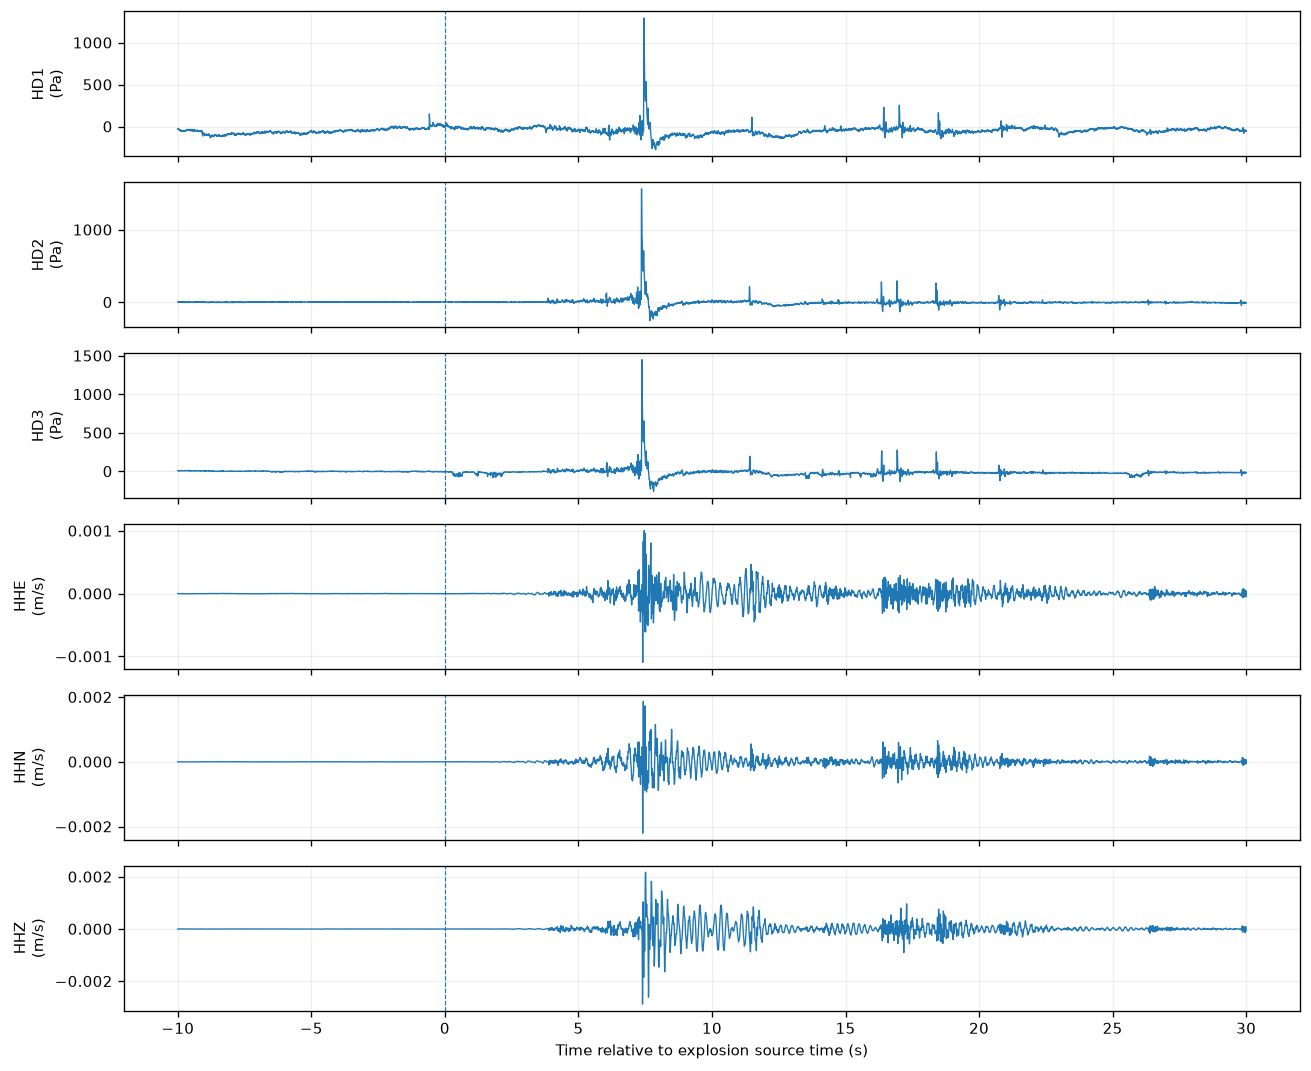

In [17]:
fig, axes = plt.subplots(len(CHANNEL_ORDER), 1, figsize=(11, 9), sharex=True)
for ax, channel in zip(axes, CHANNEL_ORDER):
    matches = st_corrected.select(channel=channel)
    if not matches:
        ax.set_visible(False)
        continue
    trace = matches[0].copy().trim(CHECK_START, CHECK_END)
    time_s = trace.times() + float(trace.stats.starttime - EXPLOSION_TIME)
    ax.plot(time_s, trace.data, linewidth=0.8)
    ax.axvline(0.0, linestyle="--", linewidth=0.7)
    units = "Pa" if channel.startswith("HD") else "m/s"
    ax.set_ylabel(f"{channel}\n({units})")
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("Time relative to explosion source time (s)")
fig.tight_layout()
plt.show()


# Part II — corrected standalone infraBSU/NRL functions

The following functions replace the relevant experimental functionality from `build.py` and `infrabsu.py` inside this notebook.

Important corrections:

- infraBSU input units are explicitly `Pa`;
- the infraBSU sensor sensitivity is `4.6e-5 V/Pa`;
- Centaur 40 Vpp is used for BCHH, yielding `18.4 count/Pa`;
- Centaur 1 Vpp would yield `736 count/Pa`;
- there is no erroneous `18400 count/Pa` fallback;
- each requested channel receives an independent deep copy of the response;
- coordinates and epoch times are explicit arguments.


## 7. General inventory builder (corrected replacement for `build.NRL2inventory`)


In [18]:
def _make_nrl(nrl_path: Optional[Path | str] = None) -> NRL:
    """Open a local NRL when supplied; otherwise use the remote NRL service."""
    if nrl_path is not None and Path(nrl_path).is_dir():
        return NRL(str(nrl_path))
    return NRL("https://ds.iris.edu/NRL/")


def _centaur_keys(vpp: float, sample_rate_hz: float) -> list[str]:
    if float(vpp) == 40.0:
        gain_key = "40 Vpp (1)"
    elif float(vpp) == 1.0:
        gain_key = "1 Vpp (40)"
    else:
        raise ValueError(f"Centaur Vpp must be 1 or 40, got {vpp}")
    return [
        "Nanometrics", "Centaur", gain_key,
        "Off", "Linear phase", f"{int(sample_rate_hz)}",
    ]


def _sensor_keys(sensor: str) -> list[str]:
    name = sensor.strip().lower()
    if name == "infrabsu":
        raise KeyError(
            "infraBSU is not requested directly from ObsPy's NRL sensor tree. "
            "Use the sensor-template + Centaur-stage builder instead."
        )
    if name in {"tcp", "trillium compact", "trillium compact 120"}:
        return ["Nanometrics", "Trillium Compact 120 (Vault, Posthole, OBS)", "754 V/m/s"]
    if name.startswith("chap"):
        return ["Chaparral Physics", "25", "Low: 0.4 V/Pa"]
    raise ValueError(f"Unsupported sensor: {sensor}")


def responses_to_inventory(
    *,
    network: str,
    station: str,
    location: str,
    channel_codes: Iterable[str],
    response: Response,
    sample_rate_hz: float,
    latitude: float,
    longitude: float,
    elevation_m: float,
    depth_m: float,
    start_date: UTCDateTime,
    end_date: UTCDateTime,
    site_name: str = "",
    source: str = "standalone NRL builder",
) -> Inventory:
    """Create a one-station Inventory and deep-copy the response per channel."""
    channels = []
    for channel_code in channel_codes:
        channels.append(Channel(
            code=str(channel_code),
            location_code=str(location),
            latitude=float(latitude),
            longitude=float(longitude),
            elevation=float(elevation_m),
            depth=float(depth_m),
            sample_rate=float(sample_rate_hz),
            start_date=start_date,
            end_date=end_date,
            response=copy.deepcopy(response),
        ))

    sta = Station(
        code=str(station),
        latitude=float(latitude),
        longitude=float(longitude),
        elevation=float(elevation_m),
        creation_date=start_date,
        site=Site(name=site_name or station),
        channels=channels,
    )
    net = Network(code=str(network), stations=[sta], start_date=start_date, end_date=end_date)
    return Inventory(networks=[net], source=source)



def _normalize_unit_name(unit) -> str | None:
    if unit is None:
        return None
    name = getattr(unit, "name", unit if isinstance(unit, str) else None)
    if name is None:
        return None
    text = str(name).strip()
    if text.upper() in {"COUNT", "COUNTS"}:
        return "count"
    if text.upper() == "PA":
        return "Pa"
    if text.upper() == "V":
        return "V"
    return text


def _stage_gain_value(stage) -> float:
    gain = getattr(stage, "stage_gain", None)
    if gain is None:
        return 1.0
    return float(getattr(gain, "value", gain))


def _recalculate_overall_sensitivity(
    response: Response,
    frequency_hz: float = 1.0,
) -> None:
    stages = list(response.response_stages or [])
    if not stages:
        raise ValueError("Response has no stages")
    response.instrument_sensitivity = InstrumentSensitivity(
        value=float(np.prod([_stage_gain_value(stage) for stage in stages])),
        frequency=float(frequency_hz),
        input_units=_normalize_unit_name(stages[0].input_units) or "Pa",
        output_units=_normalize_unit_name(stages[-1].output_units) or "count",
    )


def _load_infrabsu_sensor_response(template_path: Path | str) -> Response:
    path = Path(template_path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(path)
    inventory = read_inventory(str(path))
    channels = [
        channel
        for network in inventory
        for station in network
        for channel in station
    ]
    if len(channels) != 1:
        raise ValueError(
            f"Expected one channel in infraBSU template {path}; "
            f"found {len(channels)}"
        )
    if channels[0].response is None:
        raise ValueError(f"No response found in infraBSU template {path}")
    return copy.deepcopy(channels[0].response)


def _build_infrabsu_centaur_response(
    *,
    sample_rate_hz: float,
    vpp: float,
    template_path: Path | str,
    nrl_path: Optional[Path | str] = None,
) -> Response:
    """Combine the infraBSU sensor template with Centaur response stages."""
    sensor_response = _load_infrabsu_sensor_response(template_path)
    sensor_stages = copy.deepcopy(sensor_response.response_stages or [])
    if not sensor_stages:
        raise ValueError("infraBSU sensor template contains no response stages")

    nrl = _make_nrl(nrl_path)
    dummy_complete = nrl.get_response(
        sensor_keys=[
            "Nanometrics",
            "Trillium Compact 120 (Vault, Posthole, OBS)",
            "754 V/m/s",
        ],
        datalogger_keys=_centaur_keys(vpp, sample_rate_hz),
    )
    dummy_stages = copy.deepcopy(dummy_complete.response_stages or [])
    if len(dummy_stages) < 2:
        raise ValueError(
            "Dummy sensor + Centaur response does not contain separable stages"
        )

    # First stage is the dummy seismometer; all later stages belong to Centaur.
    centaur_stages = dummy_stages[1:]
    combined = Response(response_stages=sensor_stages + centaur_stages)
    _recalculate_overall_sensitivity(combined, frequency_hz=1.0)
    return combined


def NRL2inventory(
    nrl_path,
    net,
    sta,
    loc,
    chans,
    datalogger="Centaur",
    sensor="TCP",
    Vpp=40,
    fsamp=100.0,
    lat=0.0,
    lon=0.0,
    elev=0.0,
    depth=0.0,
    sitename="",
    ondate=UTCDateTime(1970, 1, 1),
    offdate=UTCDateTime(2100, 1, 1),
    infrabsu_template_path: Optional[Path | str] = None,
) -> Inventory:
    """Standalone NRL builder with a special infraBSU path."""
    if datalogger.lower() != "centaur":
        raise ValueError("Only the Nanometrics Centaur is supported here")

    channel_codes = [chans] if isinstance(chans, str) else list(chans)
    sensor_name = sensor.strip().lower()

    if sensor_name == "infrabsu":
        if infrabsu_template_path is None:
            raise ValueError(
                "infrabsu_template_path is required because this ObsPy NRL "
                "tree does not expose JeffreyBJohnson/infraBSU"
            )
        response = _build_infrabsu_centaur_response(
            sample_rate_hz=fsamp,
            vpp=Vpp,
            template_path=infrabsu_template_path,
            nrl_path=nrl_path,
        )
        response_source = (
            f"infraBSU sensor template + NRL Centaur {Vpp:g} Vpp"
        )
    else:
        nrl = _make_nrl(nrl_path)
        response = nrl.get_response(
            sensor_keys=_sensor_keys(sensor),
            datalogger_keys=_centaur_keys(Vpp, fsamp),
        )
        response_source = f"NRL: {sensor} + {datalogger} {Vpp:g} Vpp"

    return responses_to_inventory(
        network=net,
        station=sta,
        location=loc,
        channel_codes=channel_codes,
        response=response,
        sample_rate_hz=fsamp,
        latitude=lat,
        longitude=lon,
        elevation_m=elev,
        depth_m=depth,
        start_date=ondate,
        end_date=offdate,
        site_name=sitename,
        source=response_source,
    )


## 8. infraBSU-specific builder (corrected replacement for `infrabsu.py`)

The direct NRL combination is preferred. A sensor-template function is retained for explicit inspection or offline reuse, but it does not depend on FLOVOpy.


In [19]:
DEFAULT_INFRABSU_SENSOR_URL = (
    "https://service.iris.edu/irisws/nrl/1/combine"
    "?instconfig=sensor_JeffreyBJohnson_infraBSU_LP21_SG0.000046_STairPressure"
    "&format=stationxml"
)


def get_infrabsu_sensor_template(
    local_filename: Path | str = "infraBSU_sensor.xml",
    url: str = DEFAULT_INFRABSU_SENSOR_URL,
    timeout_s: float = 60.0,
    overwrite: bool = False,
) -> Path:
    """Download/cache the sensor-only infraBSU StationXML without FLOVOpy dependencies."""
    path = Path(local_filename).expanduser().resolve()
    if path.exists() and not overwrite:
        return path

    import requests
    response = requests.get(url, timeout=timeout_s)
    response.raise_for_status()
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_bytes(response.content)

    # Verify that the downloaded file is readable StationXML.
    read_inventory(str(path))
    return path


def get_infrabsu_centaur(
    *,
    fsamp: float,
    vpp: float,
    network: str,
    station: str,
    location: str,
    channels: Iterable[str] | str,
    latitude: float,
    longitude: float,
    elevation: float,
    depth: float,
    start_date: UTCDateTime,
    end_date: UTCDateTime,
    template_path: Path | str,
    nrl_path: Optional[Path | str] = None,
) -> Inventory:
    """Build an infraBSU + Centaur inventory directly from the NRL.

    For the BCHH 2016 deployment use `vpp=40`, which should produce an overall
    sensitivity of 18.4 count/Pa at 1 Hz.
    """
    channel_codes = [channels] if isinstance(channels, str) else list(channels)
    return NRL2inventory(
        nrl_path=nrl_path,
        net=network,
        sta=station,
        loc=location,
        chans=channel_codes,
        datalogger="Centaur",
        sensor="infrabsu",
        Vpp=vpp,
        fsamp=fsamp,
        lat=latitude,
        lon=longitude,
        elev=elevation,
        depth=depth,
        sitename=station,
        ondate=start_date,
        offdate=end_date,
        infrabsu_template_path=template_path,
    )


## 9. Build 40 Vpp and 1 Vpp NRL responses using inventory coordinates

This cell gets the coordinates from `inventory_event`, not from hardcoded constants.


In [20]:
# Show what this ObsPy NRL client actually exposes.
nrl_diagnostic = _make_nrl(NRL_PATH)
visible_sensor_manufacturers = list(nrl_diagnostic.sensors.keys())
print("Visible NRL sensor manufacturers:", len(visible_sensor_manufacturers))
print("JeffreyBJohnson visible?", "JeffreyBJohnson" in visible_sensor_manufacturers)
print("Possible infrasound-related names:")
for manufacturer in visible_sensor_manufacturers:
    text = str(manufacturer).lower()
    if any(term in text for term in ("johnson", "infra", "bsu")):
        print("  ", manufacturer)


/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_68842/467527946.py:5: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  return NRL("https://ds.iris.edu/NRL/")


Visible NRL sensor manufacturers: 42
JeffreyBJohnson visible? False
Possible infrasound-related names:
   Johnson Infrasound


In [25]:
def station_coordinates_from_inventory(
    inventory: Inventory,
    *,
    network: str,
    station: str,
    location: str,
    channel: str,
    time: UTCDateTime,
) -> dict:
    selected = inventory.select(
        network=network,
        station=station,
        location=location,
        channel=channel,
        time=time,
    )
    channels = [cha for net in selected for sta in net for cha in sta]
    if len(channels) != 1:
        raise ValueError(f"Expected one channel for coordinate lookup, found {len(channels)}")
    cha = channels[0]
    return {
        "latitude": float(cha.latitude),
        "longitude": float(cha.longitude),
        "elevation": float(cha.elevation),
        "depth": float(cha.depth),
        "sample_rate": float(cha.sample_rate),
    }


bchh_coordinates = station_coordinates_from_inventory(
    inventory_event,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channel="DD1",
    time=EXPLOSION_TIME,
)
print(bchh_coordinates)

inv_infrabsu_nrl_40vpp = get_infrabsu_centaur(
    fsamp=bchh_coordinates["sample_rate"],
    vpp=40,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channels=["DD1", "DD2", "DD3"],
    latitude=bchh_coordinates["latitude"],
    longitude=bchh_coordinates["longitude"],
    elevation=bchh_coordinates["elevation"],
    depth=bchh_coordinates["depth"],
    start_date=READ_START,
    end_date=READ_END,
    template_path=INFRABSU_TEMPLATE_FILE,
    nrl_path=NRL_PATH,
)

inv_infrabsu_nrl_1vpp = get_infrabsu_centaur(
    fsamp=bchh_coordinates["sample_rate"],
    vpp=1,
    network=BCHH_NETWORK,
    station=BCHH_STATION,
    location=BCHH_LOCATION,
    channels=["DD1", "DD2", "DD3"],
    latitude=bchh_coordinates["latitude"],
    longitude=bchh_coordinates["longitude"],
    elevation=bchh_coordinates["elevation"],
    depth=bchh_coordinates["depth"],
    start_date=READ_START,
    end_date=READ_END,
    template_path=INFRABSU_TEMPLATE_FILE,
    nrl_path=NRL_PATH,
)


{'latitude': 28.57422161, 'longitude': -80.57241686, 'elevation': 0.0, 'depth': 0.0, 'sample_rate': 250.0}


/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_68842/467527946.py:5: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  return NRL("https://ds.iris.edu/NRL/")
/var/folders/sz/wyydztsx6q7gbrq8b1pl4fl00000gn/T/ipykernel_68842/467527946.py:5: ObsPyDeprecationWarning: 
        DEPRECATED

        Direct access to online NRL is deprecated as it will stop working when
        the original NRLv1 gets taken offline (Spring 2023), please consider
        working locally with a downloaded full copy of the old NRLv1 or new
        NRLv2 following instructions on the
        `NRL landing page <https://ds.iris.edu/ds/nrl/>`_.
        
  return NRL("htt

### Empirical calibration versus nominal 40 Vpp response

This table shows why the nominal response cannot be used as the amplitude calibration for this deployment.


In [26]:
nominal_count_per_pa = 18.4
calibration_comparison_df = active_pressure_calibration_df[
    ["waveform_channel", "calib", "count_per_unit"]
].copy()
calibration_comparison_df = calibration_comparison_df.rename(
    columns={
        "calib": "empirical_pa_per_count",
        "count_per_unit": "empirical_count_per_pa",
    }
)
calibration_comparison_df["nominal_count_per_pa"] = nominal_count_per_pa
calibration_comparison_df["empirical_to_nominal_pa_per_count"] = (
    calibration_comparison_df["empirical_pa_per_count"]
    / (1.0 / nominal_count_per_pa)
)
display(calibration_comparison_df)


,waveform_channel,empirical_pa_per_count,empirical_count_per_pa,nominal_count_per_pa,empirical_to_nominal_pa_per_count
0,HD1,0.1234,8.103728,18.4,2.27056
1,HD2,1.4499,0.689703,18.4,26.67816
2,HD3,0.1000,10.000000,18.4,1.84000


## 10. Stage-by-stage response inspection


In [27]:
def response_stage_table(inventory: Inventory, seed_id: str, time: UTCDateTime) -> pd.DataFrame:
    response = inventory.get_response(seed_id, time)
    sensitivity = response.instrument_sensitivity
    rows = [{
        "stage": 0,
        "type": "Overall sensitivity",
        "gain": float(sensitivity.value),
        "gain_frequency_hz": float(sensitivity.frequency),
        "input_units": str(sensitivity.input_units),
        "output_units": str(sensitivity.output_units),
    }]
    for stage in response.response_stages:
        rows.append({
            "stage": int(stage.stage_sequence_number),
            "type": type(stage).__name__,
            "gain": None if stage.stage_gain is None else float(stage.stage_gain),
            "gain_frequency_hz": None if stage.stage_gain_frequency is None else float(stage.stage_gain_frequency),
            "input_units": str(stage.input_units),
            "output_units": str(stage.output_units),
        })
    return pd.DataFrame(rows)


for label, inventory in [
    ("Event StationXML", inventory_event),
    ("NRL 40 Vpp", inv_infrabsu_nrl_40vpp),
    ("NRL 1 Vpp", inv_infrabsu_nrl_1vpp),
]:
    print(f"\n{label}")
    display(response_stage_table(inventory, "1R.BCHH.10.DD1", EXPLOSION_TIME))



Event StationXML


,stage,type,gain,gain_frequency_hz,input_units,output_units
0,0,Overall sensitivity,18.400000,1.0,Pa,count
1,1,PolesZerosResponseStage,0.000046,1.0,Pa,V
2,2,PolesZerosResponseStage,1.000000,1.0,V,V
3,3,CoefficientsTypeResponseStage,400000.000000,1.0,V,count
4,4,CoefficientsTypeResponseStage,1.000000,1.0,count,count
5,5,CoefficientsTypeResponseStage,1.000000,1.0,count,count
6,6,CoefficientsTypeResponseStage,1.000000,1.0,count,count



NRL 40 Vpp


,stage,type,gain,gain_frequency_hz,input_units,output_units
0,0,Overall sensitivity,18.400000,1.0,Pa,count
1,1,PolesZerosResponseStage,0.000046,1.0,Pa,V
2,2,PolesZerosResponseStage,1.000000,1.0,V,V
3,3,CoefficientsTypeResponseStage,400000.000000,1.0,V,COUNTS
4,4,CoefficientsTypeResponseStage,1.000000,1.0,COUNTS,COUNTS
5,5,CoefficientsTypeResponseStage,1.000000,1.0,COUNTS,COUNTS
6,6,CoefficientsTypeResponseStage,1.000000,1.0,COUNTS,COUNTS



NRL 1 Vpp


,stage,type,gain,gain_frequency_hz,input_units,output_units
0,0,Overall sensitivity,736.000000,1.0,Pa,count
1,1,PolesZerosResponseStage,0.000046,1.0,Pa,V
2,2,PolesZerosResponseStage,40.000000,1.0,V,V
3,3,CoefficientsTypeResponseStage,400000.000000,1.0,V,COUNTS
4,4,CoefficientsTypeResponseStage,1.000000,1.0,COUNTS,COUNTS
5,5,CoefficientsTypeResponseStage,1.000000,1.0,COUNTS,COUNTS
6,6,CoefficientsTypeResponseStage,1.000000,1.0,COUNTS,COUNTS


## 11. Frequency-response comparison

This compares amplitude and phase rather than only the nominal sensitivity at 1 Hz.


In [28]:
def evaluate_response_at_frequencies(
    inventory: Inventory,
    seed_id: str,
    time: UTCDateTime,
    target_frequencies_hz: Iterable[float],
    sample_rate_hz: float,
    nfft: int = 2 ** 18,
) -> pd.DataFrame:
    response = inventory.get_response(seed_id, time)
    complex_response, frequencies = response.get_evalresp_response(
        t_samp=1.0 / sample_rate_hz,
        nfft=nfft,
        output="DEF",
    )
    rows = []
    for target in target_frequencies_hz:
        index = int(np.argmin(np.abs(frequencies - float(target))))
        value = complex_response[index]
        rows.append({
            "frequency_hz": float(frequencies[index]),
            "amplitude_count_per_pa": float(np.abs(value)),
            "phase_deg": float(np.degrees(np.angle(value))),
        })
    return pd.DataFrame(rows)


TEST_FREQUENCIES_HZ = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 80, 100]
comparison_tables = []
for label, inventory in [
    ("event_stationxml", inventory_event),
    ("nrl_40vpp", inv_infrabsu_nrl_40vpp),
    ("nrl_1vpp", inv_infrabsu_nrl_1vpp),
]:
    table = evaluate_response_at_frequencies(
        inventory,
        "1R.BCHH.10.DD1",
        EXPLOSION_TIME,
        TEST_FREQUENCIES_HZ,
        bchh_coordinates["sample_rate"],
    )
    table.insert(0, "source", label)
    comparison_tables.append(table)

nrl_response_comparison_df = pd.concat(comparison_tables, ignore_index=True)
nrl_response_comparison_df.to_csv(NRL_COMPARISON_CSV, index=False)
display(nrl_response_comparison_df)


,source,frequency_hz,amplitude_count_per_pa,phase_deg
0,event_stationxml,0.009537,3.585665,78.762693
1,event_stationxml,0.020027,7.085109,67.352523
2,event_stationxml,0.049591,13.221127,44.065978
3,event_stationxml,0.100136,16.592237,25.610692
4,event_stationxml,0.200272,17.893250,13.478103
5,event_stationxml,0.499725,18.315705,5.486588
6,event_stationxml,1.000404,18.378860,2.746980
7,event_stationxml,1.999855,18.394705,1.374935
8,event_stationxml,5.000114,18.399155,0.550010
9,event_stationxml,10.000229,18.399791,0.275011


In [29]:
amplitude_pivot = nrl_response_comparison_df.pivot(
    index="frequency_hz",
    columns="source",
    values="amplitude_count_per_pa",
)
amplitude_pivot["nrl_40vpp_to_event"] = (
    amplitude_pivot["nrl_40vpp"] / amplitude_pivot["event_stationxml"]
)
amplitude_pivot["nrl_1vpp_to_event"] = (
    amplitude_pivot["nrl_1vpp"] / amplitude_pivot["event_stationxml"]
)
display(amplitude_pivot)


source,event_stationxml,nrl_1vpp,nrl_40vpp,nrl_40vpp_to_event,nrl_1vpp_to_event
frequency_hz,,,,,
0.009537,3.585665,143.426582,3.585665,1.0,40.0
0.020027,7.085109,283.404346,7.085109,1.0,40.0
0.049591,13.221127,528.845088,13.221127,1.0,40.0
0.100136,16.592237,663.689489,16.592237,1.0,40.0
0.200272,17.893250,715.729988,17.893250,1.0,40.0
0.499725,18.315705,732.628212,18.315705,1.0,40.0
1.000404,18.378860,735.154386,18.378860,1.0,40.0
1.999855,18.394705,735.788198,18.394705,1.0,40.0
5.000114,18.399155,735.966218,18.399155,1.0,40.0


## 12. Data-domain comparison: sensitivity-only pressure

This test should give identical waveforms for the event StationXML and NRL 40 Vpp inventories when their overall sensitivities agree. The 1 Vpp result should be smaller by a factor of 40.


In [30]:
def pressure_from_inventory_sensitivity(
    raw_trace,
    inventory: Inventory,
    inventory_seed_id: str,
    baseline_start: UTCDateTime,
    baseline_end: UTCDateTime,
):
    response = inventory.get_response(inventory_seed_id, raw_trace.stats.starttime)
    sensitivity = response.instrument_sensitivity
    if str(sensitivity.input_units).lower() != "pa":
        raise ValueError(f"Expected Pa, got {sensitivity.input_units}")

    out = raw_trace.copy()
    out.data = np.asarray(out.data, dtype=np.float64) / float(sensitivity.value)
    out.data -= median_in_window(out, baseline_start, baseline_end)
    out.stats.units = "Pa"
    return out


data_domain_rows = []
for waveform_channel, xml_channel in [("HD1", "DD1"), ("HD2", "DD2"), ("HD3", "DD3")]:
    raw_trace = st_raw.select(channel=waveform_channel)[0]
    for label, inventory in [
        ("event_stationxml", inventory_event),
        ("nrl_40vpp", inv_infrabsu_nrl_40vpp),
        ("nrl_1vpp", inv_infrabsu_nrl_1vpp),
    ]:
        corrected = pressure_from_inventory_sensitivity(
            raw_trace,
            inventory,
            f"{BCHH_NETWORK}.{BCHH_STATION}.{BCHH_LOCATION}.{xml_channel}",
            PRESSURE_BASELINE_START,
            PRESSURE_BASELINE_END,
        ).trim(CHECK_START, CHECK_END)
        data = np.asarray(corrected.data, dtype=np.float64)
        data_domain_rows.append({
            "channel": waveform_channel,
            "response_source": label,
            "minimum_pa": float(np.nanmin(data)),
            "maximum_pa": float(np.nanmax(data)),
            "peak_absolute_pa": float(np.nanmax(np.abs(data))),
            "peak_to_peak_pa": float(np.nanmax(data) - np.nanmin(data)),
        })

data_domain_comparison_df = pd.DataFrame(data_domain_rows)
display(data_domain_comparison_df)


,channel,response_source,minimum_pa,maximum_pa,peak_absolute_pa,peak_to_peak_pa
0,HD1,event_stationxml,-122.010870,569.891304,569.891304,691.902174
1,HD1,nrl_40vpp,-122.010870,569.891304,569.891304,691.902174
2,HD1,nrl_1vpp,-3.050272,14.247283,14.247283,17.297554
3,HD2,event_stationxml,-9.565217,58.641304,58.641304,68.206522
4,HD2,nrl_40vpp,-9.565217,58.641304,58.641304,68.206522
5,HD2,nrl_1vpp,-0.239130,1.466033,1.466033,1.705163
6,HD3,event_stationxml,-142.336957,787.119565,787.119565,929.456522
7,HD3,nrl_40vpp,-142.336957,787.119565,787.119565,929.456522
8,HD3,nrl_1vpp,-3.558424,19.677989,19.677989,23.236413


## 13. Optional full-deconvolution comparison for infraBSU

This is deliberately diagnostic, not the production method. It demonstrates how strongly the result depends on low-frequency stabilization. Do not run with both `pre_filt=None` and `water_level=None`.


In [31]:
def full_infrasound_deconvolution(
    raw_trace,
    inventory: Inventory,
    inventory_seed_id: str,
    *,
    pre_filt=(0.05, 0.1, 80.0, 100.0),
    water_level_db=60.0,
):
    out = raw_trace.copy()
    parts = inventory_seed_id.split(".")
    out.stats.network, out.stats.station, out.stats.location, out.stats.channel = parts
    out.detrend("demean")
    out.detrend("linear")
    out.taper(max_percentage=0.05, type="cosine")
    out.remove_response(
        inventory=inventory,
        output="DEF",
        pre_filt=pre_filt,
        water_level=water_level_db,
        zero_mean=False,
        taper=False,
    )
    out.stats.units = "Pa"
    return out


# Example for HD1. Change RUN_FULL_INFRASOUND_DECONVOLUTION to True to execute.
RUN_FULL_INFRASOUND_DECONVOLUTION = False
if RUN_FULL_INFRASOUND_DECONVOLUTION:
    raw_hd1 = st_raw.select(channel="HD1")[0]
    full_event = full_infrasound_deconvolution(
        raw_hd1, inventory_event, "1R.BCHH.10.DD1"
    ).trim(CHECK_START, CHECK_END)
    full_nrl = full_infrasound_deconvolution(
        raw_hd1, inv_infrabsu_nrl_40vpp, "1R.BCHH.10.DD1"
    ).trim(CHECK_START, CHECK_END)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(full_event.times(), full_event.data, label="Event StationXML", linewidth=0.8)
    ax.plot(full_nrl.times(), full_nrl.data, label="NRL 40 Vpp", linewidth=0.8, alpha=0.75)
    ax.set_xlabel("Time from comparison-window start (s)")
    ax.set_ylabel("Pressure (Pa)")
    ax.legend()
    ax.grid(alpha=0.2)
    fig.tight_layout()
    plt.show()


## 14. Expected interpretation

A successful run should show:

- event StationXML infraBSU sensitivity: approximately **18.4 count/Pa**;
- NRL 40 Vpp sensitivity: approximately **18.4 count/Pa**;
- NRL 1 Vpp sensitivity: approximately **736 count/Pa**;
- NRL 40 Vpp / event response amplitude ratio near 1 through the useful passband;
- sensitivity-corrected event and NRL 40 Vpp waveforms numerically identical apart from floating-point roundoff;
- the 1 Vpp pressure waveform smaller by a factor of approximately 40.

The output bundle in `outputs/response_correction/` can then be consumed by the figure-generation notebook without repeating calibration experiments.
